This notebook demonstrates a simple linear regression analysis using [Python/R] to model Salary based on Years of Experience.

In [27]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score

Define the dataset and columns

In [28]:
filename = "regression_data.csv"
x_column = "YearsExperience"
y_column = "Salary"

Load the dataset

In [29]:
dataset = pd.read_csv("../regression_data.csv")
dataset.head()

,YearsExperience,Salary
0,1.1,39343.0
1,1.3,46205.0
2,1.5,37731.0
3,2.0,43525.0
4,2.2,39891.0


Plot Size, Title, Axis units, Axises tites, and Grid

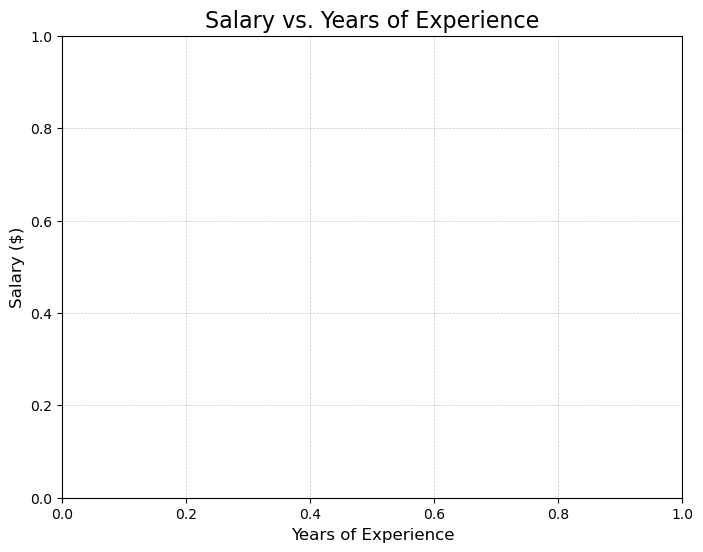

In [46]:
plt.figure(figsize=(8, 6))

plt.title("Salary vs. Years of Experience", fontsize=16)
plt.xlabel("Years of Experience", fontsize=12)
plt.ylabel("Salary ($)", fontsize=12)

plt.grid(
    True,
    linestyle="--",
    linewidth=0.5,
    alpha=0.7
)

Scatter plot

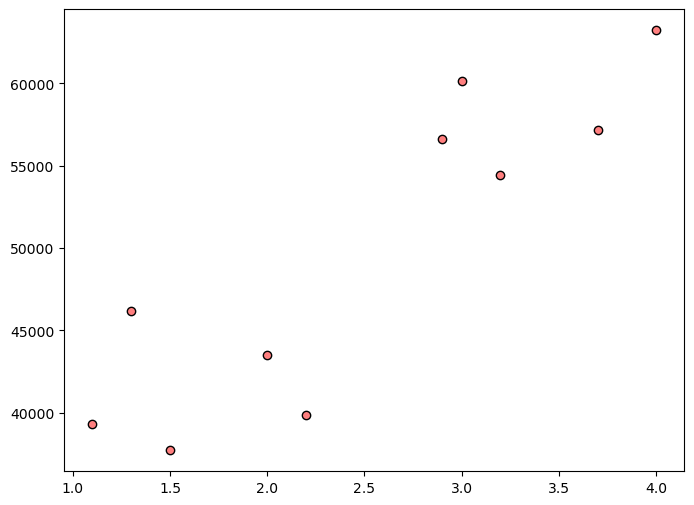

In [43]:
plt.figure(figsize=(8, 6))

plt.scatter(
    dataset[x_column],
    dataset[y_column],
    color=(1, 0, 0, 0.5),
    edgecolors="black"
)

Linear Regression

Create and fit the linear regression model.

In [44]:
model = LinearRegression()
model.fit(dataset[[x_column]], dataset[[y_column]])

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


Calculate fitted values

In [45]:
predictions = model.predict(dataset[[x_column]])

Extract regression statistics

In [36]:
slope = model.coef_[0][0]
intercept = model.intercept_[0]
r2 = r2_score(dataset[y_column], predictions)

Print model results

In [37]:
print(f"Slope: {slope:.2f}")
print(f"Intercept: {intercept:.2f}")
print(f"R-squared: {r2:.3f}")
print(f"Regression equation: y = {slope:.2f}x + {intercept:.2f}")

Slope: 8285.29
Intercept: 29203.52
R-squared: 0.785
Regression equation: y = 8285.29x + 29203.52


Original Data

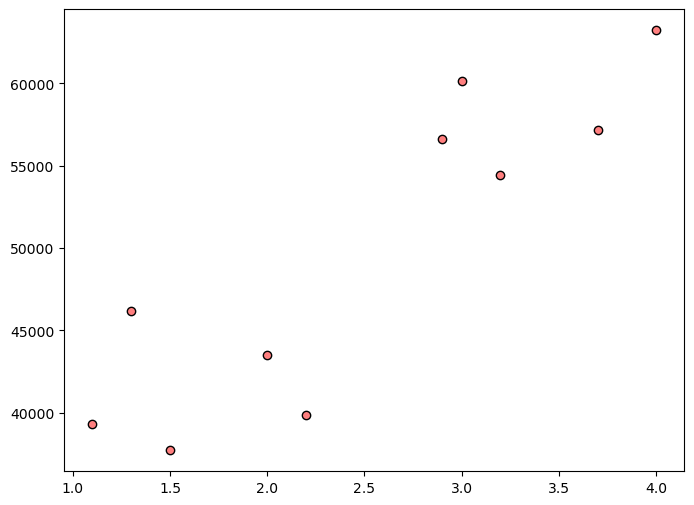

In [47]:
plt.figure(figsize=(8, 6))

plt.scatter(
    dataset[x_column],
    dataset[y_column],
    color=(1, 0, 0, 0.5),
    edgecolors="black",
    label="Observed Data"
)

Regression Line, Legend, and R2

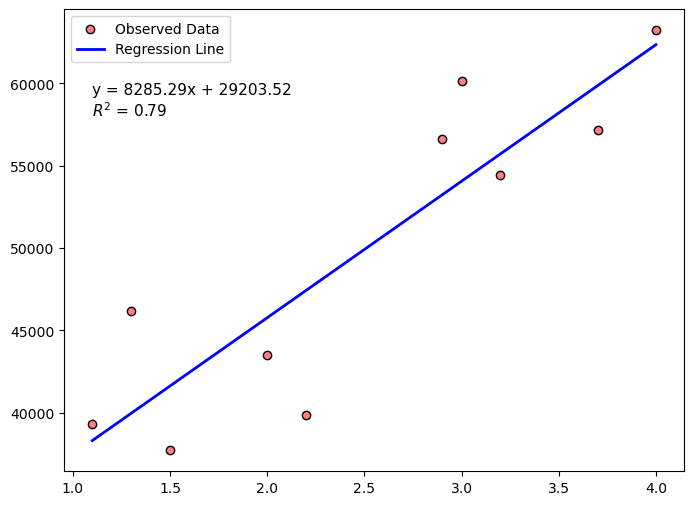

In [63]:
plt.figure(figsize=(8,6))

plt.scatter(
    dataset[x_column],
    dataset[y_column],
    color=(1,0,0,0.5),
    edgecolors="black",
    label="Observed Data"
)

plt.plot(
    dataset[x_column],
    predictions,
    color="blue",
    linewidth=2,
    label="Regression Line"
)

plt.text(
    1.1,
    58000,
    f"y = {slope:.2f}x + {intercept:.2f}\n"
    f"$R^2$ = {r2:.2f}",
    fontsize=11
)

plt.legend()
plt.show()

Predicted value

In [65]:
years_to_predict = 6

prediction_input = pd.DataFrame(
    {x_column: [years_to_predict]}
)

predicted_salary = model.predict(prediction_input)[0][0]

print(
    f"Predicted salary for {years_to_predict} years "
    f"of experience: ${predicted_salary:,.2f}"
)

Predicted salary for 6 years of experience: $78,915.28


Plotted prediction

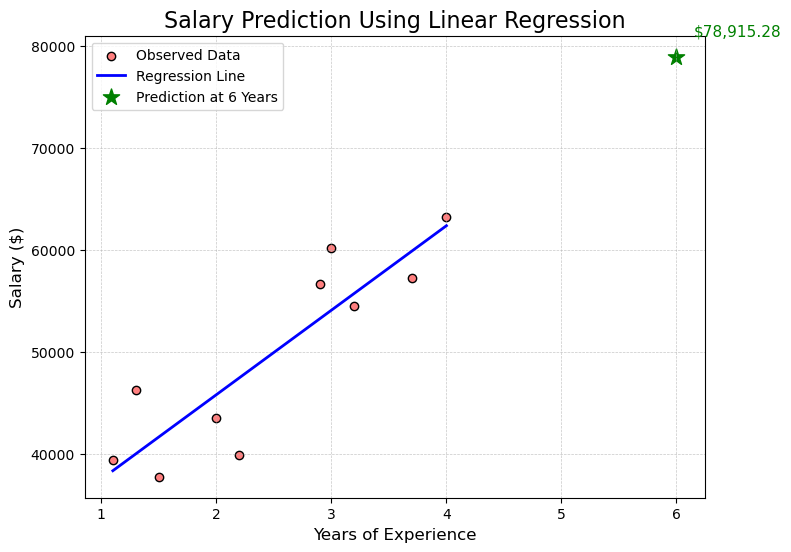

In [66]:
plt.figure(figsize=(8, 6))

# Original data
plt.scatter(
    dataset[x_column],
    dataset[y_column],
    color=(1, 0, 0, 0.5),
    edgecolors="black",
    label="Observed Data"
)

# Regression line
plt.plot(
    dataset[x_column],
    predictions,
    color="blue",
    linewidth=2,
    label="Regression Line"
)

# Predicted point
plt.scatter(
    years_to_predict,
    predicted_salary,
    color="green",
    s=150,
    marker="*",
    label=f"Prediction at {years_to_predict} Years"
)

# Predicted salary label
plt.text(
    years_to_predict + 0.15,
    predicted_salary + 2000,
    f"${predicted_salary:,.2f}",
    fontsize=11,
    color="green"
)

plt.title("Salary Prediction Using Linear Regression", fontsize=16)
plt.xlabel("Years of Experience", fontsize=12)
plt.ylabel("Salary ($)", fontsize=12)

plt.grid(
    True,
    linestyle="--",
    linewidth=0.5,
    alpha=0.7
)

plt.legend()
plt.show()

In [16]:
model.score(dataset[["YearsExperience"]], dataset[["Salary"]])  # R-squared

0.7851515863136573